In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

We can implement the CHSH game, together with the quantum strategy defined above, in Qiskit as follows.

First, here's the definition of the game itself, which allows an arbitrary strategy to be plugged in as an argument.

In [3]:
def chsh_game(strategy):
    # This function runs the CHSH game, using the strategy (a function
    # from two bits to two bits), returning 1 for a win and 0 for a loss.

    # Choose questions x & y randomly.
    x, y = random.randint(0, 1), random.randint(0, 1)

    # Use the strategy to determine a & b.
    a, b = strategy(x, y)

    # Decide if the strategy wins or loses.
    if (a != b) == (x & y):
        return 1 # Win
    return 0 # Lose

---

### The $R_y$ Gate

The Qiskit `ry(θ)` gate rotates a qubit by an angle $θ$ about the **$y$-axis** of the Bloch sphere.

Its matrix representation is

$$
R_y(\theta)=
\begin{bmatrix}
\cos(\theta/2) & -\sin(\theta/2)\\
\sin(\theta/2) & \cos(\theta/2)
\end{bmatrix}.
$$

> **Why is there a $θ/2$?**  
> In quantum mechanics, single-qubit rotations are represented by unitary operators generated from the Pauli matrices. This naturally introduces a **half-angle**, so a physical rotation of $θ$ corresponds to the matrix above.

For example,

$$
R_y(\pi/4)=
\begin{bmatrix}
\cos(\pi/8) & -\sin(\pi/8)\\
\sin(\pi/8) & \cos(\pi/8)
\end{bmatrix},
$$

and

$$
R_y(-\pi/4)=
\begin{bmatrix}
\cos(\pi/8) & \sin(\pi/8)\\
-\sin(\pi/8) & \cos(\pi/8)
\end{bmatrix}.
$$

Thus, `ry(θ)` changes the measurement basis by rotating the qubit before it is measured in the computational ($Z$) basis.

___
Now we'll create a function that outputs a circuit depending on the questions for Alice and Bob. We'll let the qubits have their default names for simplicity, and we'll use the built-in $Ry(θ)$ gate for Alice and Bob's actions.

In [4]:
def chsh_circuit(x, y):
    # This function creates a `QuantumCircuit` implementing the quantum
    # strategy described above (including the e-bit preparation).

    qc = QuantumCircuit(2, 2)

    # Prepare an e-bit
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # Alice's actions.
    if (x == 0):
        qc.ry(0, 0)
    else:
        qc.ry(-pi/2, 0) # Apply U(π/4)
    qc.measure(0, 0)

    # Bob's actions
    if y == 0:
        qc.ry(-pi / 4, 1)
    else:
        qc.ry(pi / 4, 1)
    qc.measure(1, 1)

    return qc

(x,y) = (0,0)


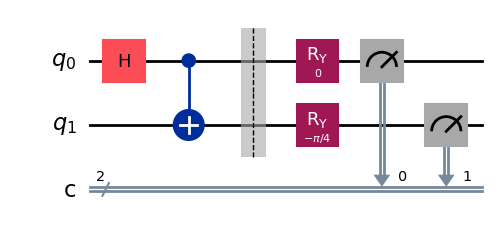

(x,y) = (0,1)


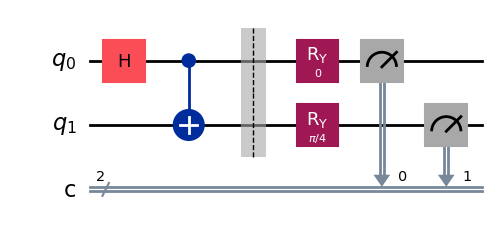

(x,y) = (1,0)


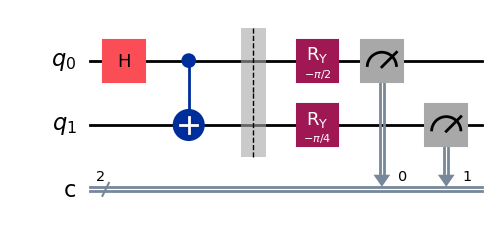

(x,y) = (1,1)


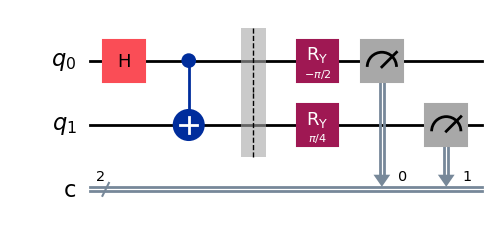

In [5]:
# Draw the four possible circuits.

print("(x,y) = (0,0)")
display(chsh_circuit(0,0).draw(output="mpl"))

print("(x,y) = (0,1)")
display(chsh_circuit(0, 1).draw(output="mpl"))

print("(x,y) = (1,0)")
display(chsh_circuit(1, 0).draw(output="mpl"))

print("(x,y) = (1,1)")
display(chsh_circuit(1, 1).draw(output="mpl"))

___
### Note on Bob's Measurement Settings

The lesson states:

- $y = 0 \rightarrow U_{\pi/8}$
- $y = 1 \rightarrow U_{-\pi/8}$

However, the IBM implementation swaps the signs:

- $y = 0 \rightarrow R_y(-\pi/4)$
- $y = 1 \rightarrow R_y(\pi/4)$

This is still correct. The Bell state

$$
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}
$$

is symmetric, so flipping both of Bob's measurement bases (or equivalently relabeling Bob's output bit) gives an **equivalent quantum strategy** with the same optimal CHSH winning probability,

$$
\cos^2\left(\frac{\pi}{8}\right) \approx 85.4\%.
$$

This still achieves the **Tsirelson bound**.

> **Note:** Since $\cos(\theta)$ is an **even function**, $\cos(-\theta)=\cos(\theta)$, changing the sign of the measurement angle does not affect the optimal success probability.

___
Now we'll create a job using the Aer simulator that runs the circuit a single time for a given input pair 
$(x,y)$.

In [8]:
def quantum_strategy(x, y):
    # This function runs the appropriate quantum circuit defined above
    # one time and returns the measurement results.

    # Setting `shots=1` to run the circuit once.
    result = AerSimulator().run(chsh_circuit(x, y), shots=1).result()
    statistics = result.get_counts()

    # Determine the output bits and return them.
    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]

    return a, b

Finally, we'll play the game 1000 times and compute the fraction that the strategy wins.

In [9]:
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(quantum_strategy)

print(TOTAL_SCORE)
print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

846
Fraction of games won: 0.846


___
We can also define a classical strategy and see how well it works. 

This is just one strategy — others can be tested by changing the code — but it is among the optimal classical strategies.

In [10]:
def classical_strategy(x, y):
    # This function implements just one example of an optimal classical
    # strategy for the CHSH game. Other classical strategies can be
    # implemented by changing the bit values assigned to a and b.

    # Alice's answer
    if x == 0:
        a = 0
    elif x == 1:
        a = 1

    # Bob's answer
    if y == 0:
        b = 1
    elif y == 1:
        b = 0

    return a, b

Again let's play the game 1000 times to see how well it works.

In [14]:
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(classical_strategy)

print(TOTAL_SCORE)
print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

756
Fraction of games won: 0.756


___
Although there's randomness involved, the statistics are very unlikely to deviate too much after 1000 runs. 

The quantum strategy wins about 85% of the time while a classical strategy can't win more than about 75% of the time.